# Instructions

- This homework assignment is worth 39 points. 
- Please strive for clarity and organization.
- **AI Usage**:
   - AI use is strictly **prohibited** for conceptual exercises.
   - For applied (Python) exercises, you may only use AI for **debugging**. Do not use AI to generate answers.
- **Due Date: September 19, 2025, by 11:59 PM.**

# Exercise 1 

In this exercise, we will work with the `winemag-data-130k-v2.csv` data file. This file contains information about wine. The goal is to explore this data using the NLP techniques that we have learnt. For more information about the data file, see this [link](https://www.kaggle.com/datasets/zynicide/wine-reviews/data).

### Exercise 1(a) (2 points)

Load the following libraries:

- `pandas`
- `numpy`
- `matplotlib.pyplot`
- `wordcloud`

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import wordcloud 

### Exercise 1(b) (2 points)

Read the `csv` file and create a data-frame called `wine_df`.

In [2]:
wine_df = pd.read_csv('winemag-data-130k-v2.csv')
wine_df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


### Exercise 1(c) (2 points)

Report the `shape` of `wine_df`.

In [3]:
wine_df.shape

(129971, 14)

### Exercise 1(d) (2 points)

Report the number of wine types in the `wine_df` data frame.

In [8]:
wine_df['variety'].nunique()

707

### Exercise 1(e) (2 points)

Report the number countries producing wine in the `wine_df` data frame.

In [12]:
wine_df['country'].nunique()

43

### Exercise 1(f) (4 points)

Report the country with the highest and lowest average `points`.

In [16]:
wine_df['points'].groupby(wine_df['country']).mean().sort_values(ascending=False).head(1)

country
England    91.581081
Name: points, dtype: float64

In [17]:
wine_df['points'].groupby(wine_df['country']).mean().sort_values(ascending=False).tail(1)

country
Peru    83.5625
Name: points, dtype: float64

### Exercise 1(g) (3 points)

Using the `string` library, remove all the punctuation of the `description` column and store the results in another column called `description_clean`.

In [18]:
import string

wine_df['description_clean'] = wine_df['description'].str.replace(f"[]{string.punctuation}]", '', regex=True)
wine_df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,description_clean
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Aromas include tropical fruit broom brimstone ...
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,This is ripe and fruity a wine that is smooth ...
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,Tart and snappy the flavors of lime flesh and ...
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,Pineapple rind lemon pith and orange blossom s...
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,Much like the regular bottling from 2012 this ...


### Exercise 1(h) (10 points)

Using the `nltk` library, remove stopwords, pronouns, and the following words: `drink`, `now`, `wine`, `flavor`, and `flavors` from `description_clean` and store in another column called `'description_clean_1'`. 

In [20]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stopwords = set(stopwords.words('english'))
pronouns = set(['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves'])
others = set(['drink', 'now', 'wine', 'flavor', 'flavors'])

def clean_text(text):
    tokens = word_tokenize(text.lower())
    tokens = [word for word in tokens if word not in stopwords and word not in pronouns and word not in others]
    return ' '.join(tokens)

wine_df['description_clean_1'] = wine_df['description_clean'].apply(clean_text)
wine_df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,description_clean,description_clean_1
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia,Aromas include tropical fruit broom brimstone ...,aromas include tropical fruit broom brimstone ...
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos,This is ripe and fruity a wine that is smooth ...,ripe fruity smooth still structured firm tanni...
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm,Tart and snappy the flavors of lime flesh and ...,tart snappy lime flesh rind dominate green pin...
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian,Pineapple rind lemon pith and orange blossom s...,pineapple rind lemon pith orange blossom start...
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks,Much like the regular bottling from 2012 this ...,much like regular bottling 2012 comes across r...


### Exercise 1(i) (6 points)

Create a data frame called `England` with wines from `England`, and create a word cloud of `description_clean_1`.

Text(0.5, 1.0, 'England df Word Cloud')

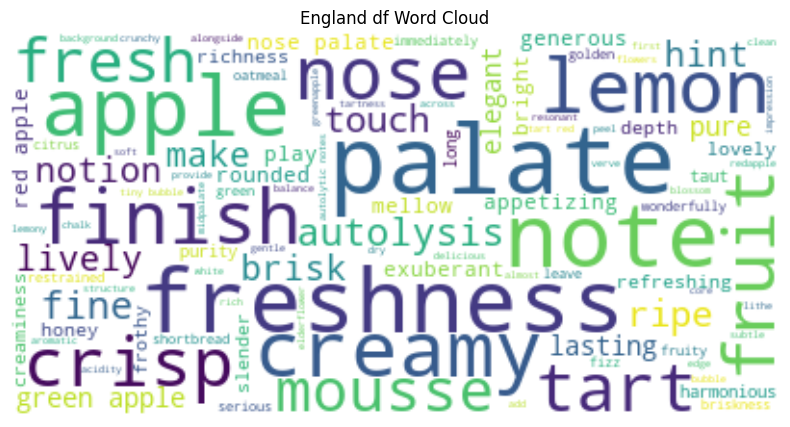

In [21]:
from wordcloud import WordCloud

england = wine_df[wine_df['country'] == 'England']

wordcloud = WordCloud(max_font_size=50, max_words=100, background_color='white').generate(' '.join(england['description_clean_1']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('England df Word Cloud')

### Exercise 1(j) (6 points)

Create a data frame called `Peru` with wines from `Peru`, and create a word cloud of `description_clean_1`.

Text(0.5, 1.0, 'Peru df Word Cloud')

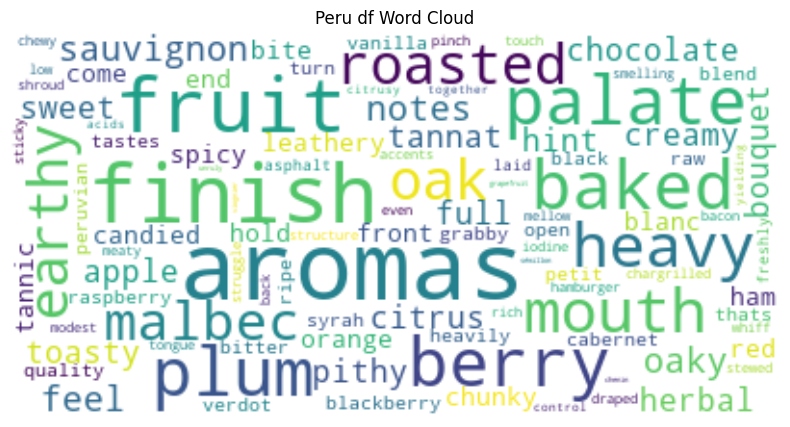

In [22]:
peru = wine_df[wine_df['country'] == 'Peru']

wordcloud = WordCloud(max_font_size=50, max_words=100, background_color='white').generate(' '.join(peru['description_clean_1']))
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Peru df Word Cloud')